# Lab 09 — Input normalization, mini-batch และ optimizers
### Why normalize, batch vs mini-batch vs SGD, momentum / RMSprop / Adam

**กลุ่ม:** C neural network · **อ่านคู่กับสไลด์หน้า:** 97-114 · **เวลาโดยประมาณ:** 90 นาที · **Dataset:** ข้อมูล 2 มิติสังเคราะห์ที่ feature มี scale ต่างกัน, nnlab.data.get_dataset('churn'), nnlab.data.load_breast_cancer_scaled

**ควรทำมาก่อน:** Lab 07-08 (`NeuralNetwork`, forward/backward ระดับล่าง และ validation set)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. normalize input ด้วย $\mu$ และ $\sigma$ ของ training set (สไลด์ p.98-99) และอธิบายด้วย contour ว่าทำไม gradient descent เร็วขึ้น (p.100)
2. แบ่งข้อมูลเป็น mini-batch $X^{\{t\}}, Y^{\{t\}}$ ด้วย permutation (p.102-103) และอ่าน cost ที่แกว่งของ mini-batch GD ได้ (p.104)
3. เลือกขนาด mini-batch ตามกติกา p.105-106 (batch / mini-batch / stochastic และ $m \le 2000$ → batch)
4. เขียน Momentum, RMSprop และ Adam ตามสูตร p.109-113 พร้อม bias correction (p.112) และเห็นเส้นทางของแต่ละตัวบน contour (p.108)
5. เทียบ optimizer ที่เขียนเองกับ `nnlab.optimizers` และ `torch.optim` ทีละก้าว รวมถึงข้อต่างเรื่อง $(1-\beta)$ ของ momentum (p.110)
6. ใช้ learning rate decay (p.114), `DataLoader` ของ torch และ `TorchTrainer(optimizer='adam')` กับข้อมูลจริง

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)
lab นี้ใช้ PyTorch (เทียบ optimizer และ DataLoader) และ pandas (ตารางผล) เพิ่มจาก numpy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import torch
from torch import nn
import pandas as pd
torch.manual_seed(463)
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ใน notebook |
|---|---|---|
| $\mu = \frac{1}{m}\sum_i x^{(i)}$, $\sigma^2 = \frac{1}{m}\sum_i (x^{(i)} - \mu)^2$ | ค่าเฉลี่ยและ variance **ต่อ feature** จาก training set (p.98-99) | `X.mean(axis=0)`, `X.var(axis=0)` |
| $X^{\{t\}}, Y^{\{t\}}$ | mini-batch ที่ $t$ (วงเล็บปีกกา — ต่างจาก $x^{(i)}$ = sample ที่ $i$ และ $W^{[l]}$ = ชั้นที่ $l$) (p.102) | `X_t, Y_t` |
| $\mathcal{J}^{\{t\}}$ | cost ที่คำนวณจาก mini-batch $t$ เท่านั้น (p.103) | `cost_step` |
| $v_{dW}, v_{db}$ | "velocity" ของ momentum: ค่าเฉลี่ยถ่วงน้ำหนักของ gradient ที่ผ่านมา (p.109) | `v` |
| $s_{dW}, s_{db}$ | ค่าเฉลี่ยถ่วงน้ำหนักของ gradient **กำลังสอง** (RMSprop, p.111) | `s` |
| $\beta$ / $\beta_1, \beta_2$ | น้ำหนักของอดีต: momentum และ RMSprop ใช้ $\beta$; Adam ใช้ $\beta_1 = 0.9$, $\beta_2 = 0.999$ (p.114) | `beta`, `beta1`, `beta2` |
| $\varepsilon = 10^{-8}$ | กันหารด้วยศูนย์ใน $\sqrt{s} + \varepsilon$ (p.111) | `eps` |
| $v^{\text{correct}} = v_t / (1 - \beta^t)$ | bias correction — แก้ที่ $v$ เริ่มจาก 0 จึงเล็กเกินจริงช่วงแรก (p.112) | `v / (1 - beta ** t)` |
| $\alpha_0 / (1 + \text{decay\_rate} \cdot \text{epoch})$ | learning rate decay (p.114) | `nnlab.optimizers.lr_decay` |

## ขั้นที่ 1 · ทำไมต้อง normalize input (สไลด์ p.98-100)
ข้อมูลจริงมี feature ที่หน่วยต่างกันมาก เช่น "ชั่วโมงใช้งานต่อเดือน" อยู่ระดับ 50 ± 10 แต่ "คะแนนความพอใจ" อยู่ระดับ 5 ± 1
สไลด์ p.98-99 ทำสองขั้นกับ**ทุก feature แยกกัน**:
1. ลบค่าเฉลี่ย: $X := X - \mu$ → ทุก feature มี mean 0
2. หารด้วยส่วนเบี่ยงเบนมาตรฐาน: $X := X / \sigma$ → ทุก feature มี variance 1

**หมายเหตุสไลด์ p.99:** สไลด์เขียน $X = X / \sigma^2$ แต่ที่ทำจริง (และที่ทำให้ variance เป็น 1) คือหารด้วย $\sigma$ ไม่ใช่ $\sigma^2$ — cell นี้คำนวณทั้งสองแบบให้เห็นว่าแบบ $\sigma^2$ ได้ variance ไม่เท่ากับ 1
และกติกาสำคัญ: $\mu, \sigma$ ต้องมาจาก **training set** แล้วใช้ค่าเดิมกับ test set (p.99 "μ and σ² from training set will be used in test set") — ไม่งั้นข้อมูล test รั่วเข้ามาในการเทรน

เราสร้างข้อมูล 2 มิติสังเคราะห์ 200 จุด 2 class ที่ feature แรกมี scale ใหญ่กว่า feature ที่สอง 10 เท่า แล้ว normalize ด้วยมือเทียบกับ `nnlab.preprocessing.StandardNormalizer`

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

ก่อน normalize: mean ต่อ feature = [50.4367  4.9881] | std = [12.1297  1.4   ]
หลังลบ mean   : mean = [-0.  0.] | std = [12.1297  1.4   ]
หลังหาร σ     : mean = [-0.  0.] | std = [1. 1.]  ← variance 1 ทุก feature ✓
ถ้าหาร σ² ตามที่สไลด์เขียน: std = [0.0824 0.7143]  ← ไม่ใช่ 1 (errata p.99)
StandardNormalizer ให้ผลเท่ากับที่เขียนเอง ✓  (mean_ = [50.4367  4.9881] , std_ = [12.1297  1.4   ] )


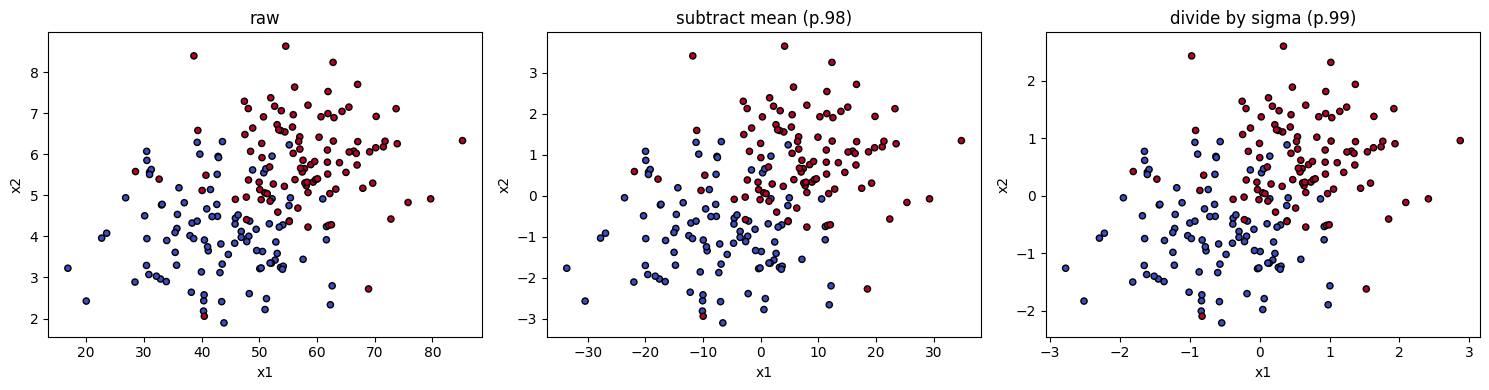

In [2]:
from nnlab.preprocessing import StandardNormalizer

m = 200
y = np.repeat([0, 1], m // 2)                                                  # y: (200,) class ละ 100
X_base = rng.standard_normal((m, 2)) + np.where(y[:, None] == 1, 0.7, -0.7)   # 2 กลุ่มซ้อนกันเล็กน้อย scale เท่ากัน
X_raw = X_base.copy()                                                          # X_raw: (200, 2) sample เป็นแถว
X_raw[:, 0] = X_base[:, 0] * 10 + 50                                           # feature 0: "ชั่วโมงใช้งาน" ~ 50 ± 10
X_raw[:, 1] = X_base[:, 1] + 5                                                 # feature 1: "คะแนน" ~ 5 ± 1
print("ก่อน normalize: mean ต่อ feature =", X_raw.mean(axis=0), "| std =", X_raw.std(axis=0))

mu = X_raw.mean(axis=0)                     # μ: (2,)  = (1/m) Σ x^(i)          (p.98)
X_centered = X_raw - mu                     # (200, 2) - (2,) broadcast ทุกแถว
sigma2 = (X_centered ** 2).mean(axis=0)     # σ²: (2,) = (1/m) Σ (x - μ)²      (p.99)
X_norm = X_centered / np.sqrt(sigma2)       # หารด้วย σ (ไม่ใช่ σ²)
print("หลังลบ mean   : mean =", X_centered.mean(axis=0), "| std =", X_centered.std(axis=0))
print("หลังหาร σ     : mean =", X_norm.mean(axis=0), "| std =", X_norm.std(axis=0), " ← variance 1 ทุก feature ✓")
print("ถ้าหาร σ² ตามที่สไลด์เขียน: std =", (X_centered / sigma2).std(axis=0), " ← ไม่ใช่ 1 (errata p.99)")

norm = StandardNormalizer().fit(X_raw)      # เก็บ μ, σ ของ training set ไว้ใช้กับข้อมูลใหม่
assert np.allclose(norm.transform(X_raw), X_norm) and np.allclose(norm.mean_, mu) and np.allclose(norm.std_, np.sqrt(sigma2))
print("StandardNormalizer ให้ผลเท่ากับที่เขียนเอง ✓  (mean_ =", norm.mean_, ", std_ =", norm.std_, ")")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (Xs, name) in zip(axes, [(X_raw, "raw"), (X_centered, "subtract mean (p.98)"), (X_norm, "divide by sigma (p.99)")]):
    ax.scatter(Xs[:, 0], Xs[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=20); ax.set_title(name); ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout(); plt.show()

### contour ของ cost ก่อน/หลัง normalize (สไลด์ p.100)
ทำไมเรื่องนี้ถึงอยู่ในบท "gradient"? เพราะ **รูปร่างของ cost function ขึ้นกับ scale ของ input**
perceptron คำนวณ $z = w_1 x_1 + w_2 x_2 + b$ — ถ้า $x_1$ ใหญ่กว่า $x_2$ สิบเท่า การขยับ $w_1$ นิดเดียวก็เปลี่ยน $z$ มหาศาล cost จึง**ชันมากในแกน $w_1$ แต่แบนในแกน $w_2$** → contour เป็นวงรียาว
gradient descent ต้องใช้ learning rate เล็กพอที่จะไม่กระเด้งในแกนชัน แล้วก็เลยคืบช้ามากในแกนแบน (p.100 ซ้าย "oscillated and take longer") หลัง normalize contour กลม เดินตรงเข้าหาจุดต่ำสุดได้ (p.100 ขวา)

cell นี้วาด cost ของ perceptron (BCE) บนตาราง $(w_1, w_2)$ โดยตรึง $b = 0$ (ข้อมูลลบ mean แล้วและสอง class สมดุล $b^*$ จึงใกล้ 0) แล้วเดิน gradient descent 60 ก้าวจากจุดเริ่มเดียวกันบนข้อมูลสองแบบ:
ซ้าย = ลบ mean แล้วแต่**ยังไม่หาร $\sigma$** (scale ต่างกัน 10 เท่า), ขวา = normalize ครบ
ใช้ deck convention เพราะสูตร perceptron จาก lab05 ต้องการ $X$ shape $(n_x, m)$

> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

cost หลัง 60 ก้าว: ไม่ normalize 0.5372 | normalize 0.2980


จำนวนก้าวจนกว่า cost < 0.31: ไม่ normalize (lr=0.07) 187 ก้าว | normalize (lr=1.0) 21 ก้าว


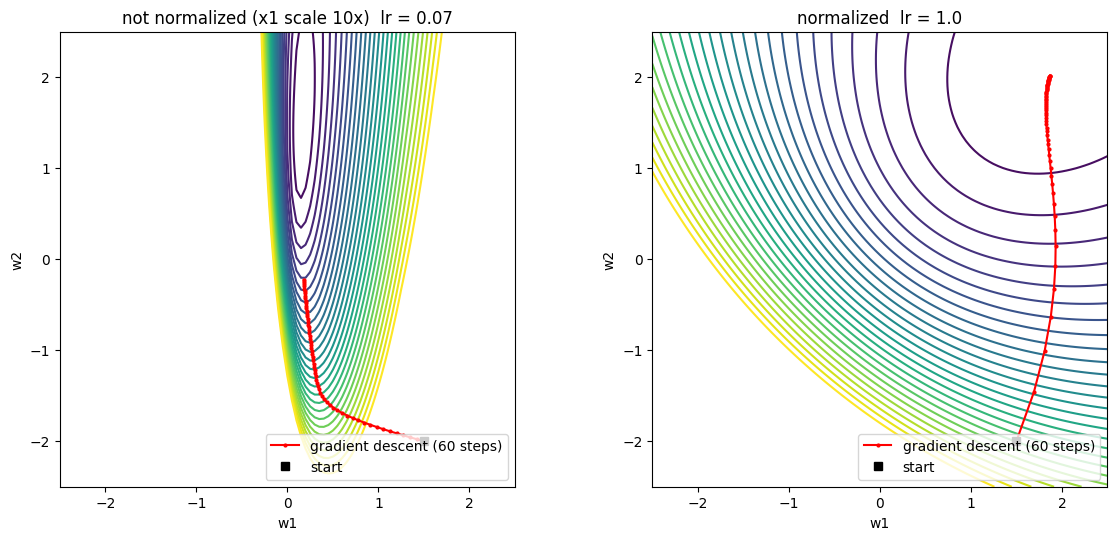

In [3]:
from nnlab.activations import sigmoid
from nnlab.losses import binary_cross_entropy
from nnlab.conventions import to_deck

X_c_deck, Y = to_deck(X_centered, y)        # (2, 200), (1, 200)  ลบ mean อย่างเดียว
X_n_deck = to_deck(X_norm)                  # (2, 200)            normalize ครบ

def cost_at(w, X_deck):
    """cost ของ perceptron ที่ w (2,) และ b = 0"""
    A = sigmoid(w.reshape(1, 2) @ X_deck)   # (1, 2) @ (2, m) → (1, m)
    return binary_cross_entropy(A, Y)

def gd_path(X_deck, lr, steps, w0):
    """gradient descent ของ perceptron (lab05): dw = (1/m) X dZᵀ  คืน path (steps+1, 2)"""
    w = np.array(w0, dtype=float); path = [w.copy()]
    for _ in range(steps):
        A = sigmoid(w.reshape(1, 2) @ X_deck)               # (1, m)
        dw = (X_deck @ (A - Y).T).ravel() / X_deck.shape[1]  # (2, m) @ (m, 1) → (2, 1) → (2,)
        w = w - lr * dw; path.append(w.copy())
    return np.array(path)

w0 = (1.5, -2.0)
lr_raw, lr_norm = 0.07, 1.0                 # lr ที่ใหญ่ที่สุดที่ยังไม่ระเบิดบนข้อมูลแต่ละแบบ (ลองเพิ่ม lr_raw เป็น 0.2 ดู)
path_raw, path_norm = gd_path(X_c_deck, lr_raw, 60, w0), gd_path(X_n_deck, lr_norm, 60, w0)

def steps_to(X_deck, lr, target=0.31, max_steps=2000):
    p = gd_path(X_deck, lr, max_steps, w0)
    ok = np.array([cost_at(w, X_deck) for w in p]) < target
    return int(np.argmax(ok)) if ok.any() else None
print(f"cost หลัง 60 ก้าว: ไม่ normalize {cost_at(path_raw[-1], X_c_deck):.4f} | normalize {cost_at(path_norm[-1], X_n_deck):.4f}")
print(f"จำนวนก้าวจนกว่า cost < 0.31: ไม่ normalize (lr={lr_raw}) {steps_to(X_c_deck, lr_raw)} ก้าว | normalize (lr={lr_norm}) {steps_to(X_n_deck, lr_norm)} ก้าว")

r = 2.5
g1, g2 = np.meshgrid(np.linspace(-r, r, 101), np.linspace(-r, r, 101))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, (X_deck, path, name) in zip(axes, [(X_c_deck, path_raw, f"not normalized (x1 scale 10x)  lr = {lr_raw}"), (X_n_deck, path_norm, f"normalized  lr = {lr_norm}")]):
    Z = np.array([[cost_at(np.array([a, b]), X_deck) for a in g1[0]] for b in g2[:, 0]])   # (101, 101)
    ax.contour(g1, g2, Z, levels=np.linspace(0.29, 1.6, 28))
    ax.plot(path[:, 0], path[:, 1], "r.-", ms=4, label="gradient descent (60 steps)")
    ax.plot(*w0, "ks", label="start"); ax.set_xlabel("w1"); ax.set_ylabel("w2"); ax.set_aspect("equal"); ax.set_title(name); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

ซ้าย: หุบเขาแคบยาว — ก้าวแรกๆ เด้งข้ามหุบเขาในแกน $w_1$ (zig-zag) แล้วค่อยๆ คืบขึ้นไปตามแกน $w_2$ 60 ก้าวยังไม่ถึง
ขวา: contour เกือบกลม — ใช้ learning rate ใหญ่กว่า 14 เท่าได้และเดินตรงเข้าจุดต่ำสุดใน ~20 ก้าว
นี่คือเหตุผลที่ `get_dataset` และ `load_breast_cancer_scaled` normalize ให้ทุกครั้ง (ด้วย $\mu, \sigma$ ของ train เท่านั้น) และเป็นสิ่งแรกที่ควรทำเมื่อโมเดล "เทรนไม่ลง"

## ขั้นที่ 2 · mini-batch gradient descent (สไลด์ p.101-106)
ที่ผ่านมาทุก epoch เราใช้ **ทั้ง $m$ sample** คำนวณ gradient หนึ่งครั้งแล้วอัปเดตหนึ่งครั้ง (batch gradient descent) ถ้า $m = 5{,}000{,}000$ (p.102) หนึ่งก้าวจะช้ามากและ memory ไม่พอ
mini-batch: สับลำดับ sample แล้วหั่น $X$ เป็นก้อนละ `batch_size` คอลัมน์ $X^{\{1\}}, X^{\{2\}}, \dots$ (p.102) แล้วทำ forward → cost $\mathcal{J}^{\{t\}}$ → backward → อัปเดต **ทุกก้อน** (p.103) — หนึ่ง epoch จึงอัปเดตหลายครั้ง

cell นี้หั่น churn training set (800 sample, 6 feature หลัง one-hot และ normalize) เป็น mini-batch ขนาด 64 ด้วยมือ:
`rng.permutation(m)` ให้ลำดับสุ่ม แล้ว slice ทีละ 64 index (ก้อนสุดท้ายเหลือ $800 - 12 \times 64 = 32$) จากนั้นเทียบกับ `nnlab.nn.iterate_minibatches` โดยให้ generator สอง ตัวเริ่มจาก seed เดียวกัน — ต้องได้ก้อนเดียวกันเป๊ะ

In [4]:
from nnlab.data import get_dataset
from nnlab.nn import iterate_minibatches

X_tr_c, X_te_c, y_tr_c, y_te_c, _ = get_dataset("churn")     # (800, 6) / (200, 6) normalize ด้วย μ,σ ของ train แล้ว
X_deck_c, Y_c = to_deck(X_tr_c, y_tr_c)                       # X_deck_c: (6, 800), Y_c: (1, 800)
m_c = X_deck_c.shape[1]
batch_size = 64

rng_a = np.random.default_rng(463)
perm = rng_a.permutation(m_c)                                 # (800,) ลำดับสุ่มของ index
print("index 10 ตัวแรกหลังสับ:", perm[:10])
batches = []
for t, start in enumerate(range(0, m_c, batch_size), start=1):
    idx = perm[start:start + batch_size]                      # (≤64,)
    X_t, Y_t = X_deck_c[:, idx], Y_c[:, idx]                   # X{t}: (6, ≤64), Y{t}: (1, ≤64)  ← เลือก "คอลัมน์"
    batches.append((X_t, Y_t))
    if t <= 3 or start + batch_size >= m_c:
        print(f"mini-batch t={t:>2}: X{{t}} {X_t.shape}  Y{{t}} {Y_t.shape}")
print(f"รวม {len(batches)} mini-batch ต่อ epoch (ceil(800/64) = 13) | sample ทั้งหมดถูกใช้ครั้งเดียว: {sorted(np.concatenate([np.flatnonzero(np.isin(perm, perm[s:s+batch_size])) for s in range(0, m_c, batch_size)])) == list(range(m_c))}")

rng_b = np.random.default_rng(463)                            # seed เดียวกับ rng_a → permutation เดียวกัน
for (X_t, Y_t), (X_lib, Y_lib) in zip(batches, iterate_minibatches(X_deck_c, Y_c, batch_size, rng_b)):
    assert np.array_equal(X_t, X_lib) and np.array_equal(Y_t, Y_lib)
print("nnlab.nn.iterate_minibatches ให้ mini-batch เดียวกับที่หั่นเอง ✓")

index 10 ตัวแรกหลังสับ: [528 711 497 718 291 113 628 247 560 441]
mini-batch t= 1: X{t} (6, 64)  Y{t} (1, 64)
mini-batch t= 2: X{t} (6, 64)  Y{t} (1, 64)
mini-batch t= 3: X{t} (6, 64)  Y{t} (1, 64)
mini-batch t=13: X{t} (6, 32)  Y{t} (1, 32)
รวม 13 mini-batch ต่อ epoch (ceil(800/64) = 13) | sample ทั้งหมดถูกใช้ครั้งเดียว: True
nnlab.nn.iterate_minibatches ให้ mini-batch เดียวกับที่หั่นเอง ✓


### training loop แบบ p.103 และ cost ที่แกว่ง (p.104)
ฟังก์ชัน `train_minibatch` ด้านล่างคือ pseudo-code ของ p.103 ตรงๆ: วน epoch → วน $t$ → forward บน $X^{\{t\}}$ → $\mathcal{J}^{\{t\}}$ → backward → อัปเดต
เราบันทึก cost 2 แบบ: `cost_step` = $\mathcal{J}^{\{t\}}$ ทุกครั้งที่อัปเดต (ใช้แค่ก้อนเดียวจึง**แกว่ง** — p.104 บอกว่าบางก้อนง่าย บางก้อนยาก แต่แนวโน้มรวมต้องลง) และ `cost_epoch` = cost ของทั้ง training set หลังจบ epoch
`optimizer` เป็น object ที่มี `step(params, grads)` — ตอนนี้ใช้ gradient descent ธรรมดา ขั้นที่ 3 จะเปลี่ยนเป็น momentum/RMSprop/Adam โดยไม่ต้องแก้ loop
เทรน network `[6, 16, 1]` สามแบบ (p.105): batch (`batch_size=None`), mini-batch 64 และ stochastic (`batch_size=1` — แค่ 5 epoch เพราะช้า) แล้วจับเวลาต่อ epoch

In [5]:
from nnlab.nn import init_params, forward, backward, compute_cost
from nnlab.utils import Timer

class GD:
    """gradient descent ธรรมดา: θ := θ − α dθ  (p.103 บรรทัดสุดท้าย)"""
    def __init__(self, lr): self.lr = lr
    def step(self, params, grads):
        for k in params:
            params[k] -= self.lr * grads["d" + k]

def train_minibatch(X_deck, Y, layer_sizes, optimizer, epochs, batch_size, seed=463, lr_schedule=None):
    """mini-batch training loop ตาม p.103 คืน params, cost_step (ต่อการอัปเดต), cost_epoch (ต่อ epoch)"""
    acts = ["relu"] * (len(layer_sizes) - 2) + ["sigmoid"]
    params = init_params(layer_sizes, seed)                   # W1 (16, 6) b1 (16, 1) W2 (1, 16) b2 (1, 1)
    rng_mb = np.random.default_rng(seed)
    cost_step, cost_epoch = [], []
    for epoch in range(epochs):
        if lr_schedule is not None:
            optimizer.lr = lr_schedule(epoch)                 # ใช้ในขั้นที่ 6 (learning rate decay)
        for X_t, Y_t in iterate_minibatches(X_deck, Y, batch_size, rng_mb):
            A_t, caches = forward(X_t, params, acts)          # A_t: (1, batch)
            cost_step.append(compute_cost(A_t, Y_t))          # J{t} จากก้อนนี้เท่านั้น
            grads = backward(Y_t, caches, params, acts)
            optimizer.step(params, grads)
        A_all, _ = forward(X_deck, params, acts)              # (1, m)
        cost_epoch.append(compute_cost(A_all, Y))
    return params, np.array(cost_step), np.array(cost_epoch)

def accuracy_of(params, X_rows, y_rows):
    A, _ = forward(to_deck(X_rows), params, ["relu", "sigmoid"])
    return float(np.mean((A.reshape(-1) >= 0.5) == y_rows))

runs, rows = {}, []
for name, bs, epochs in [("batch (m=800)", None, 60), ("mini-batch 64", 64, 60), ("stochastic (1)", 1, 5)]:
    with Timer() as t:
        params_mb, c_step, c_epoch = train_minibatch(X_deck_c, Y_c, [6, 16, 1], GD(lr=0.05), epochs, bs)
    runs[name] = (c_step, c_epoch, epochs)
    rows.append({"setting": name, "updates / epoch": len(c_step) // epochs, "epochs": epochs, "time / epoch (ms)": 1000 * t.elapsed / epochs,
                 "final cost (all m)": c_epoch[-1], "val acc": accuracy_of(params_mb, X_te_c, y_te_c)})
speed = pd.DataFrame(rows).round(4)
speed

,setting,updates / epoch,epochs,time / epoch (ms),final cost (all m),val acc
0,batch (m=800),1,60,0.1629,0.5415,0.715
1,mini-batch 64,13,60,0.7582,0.5081,0.760
2,stochastic (1),800,5,30.5610,0.5128,0.740


ซ้าย: $\mathcal{J}^{\{t\}}$ ต่อการอัปเดต (แกน x เป็นหน่วย epoch เพื่อให้เทียบกันได้) — batch เป็นเส้นเรียบ mini-batch 64 แกว่งแต่ลงเร็วกว่าเพราะอัปเดต 13 ครั้งต่อ epoch
stochastic แกว่งรุนแรง (แต่ละจุดคือ loss ของ sample เดียว) เส้นทึบคือค่าเฉลี่ยเคลื่อนที่ 50 ก้าว
ขวา: cost ของทั้ง training set ต่อ epoch — ตัวเลขที่ควรใช้ตัดสินจริงๆ

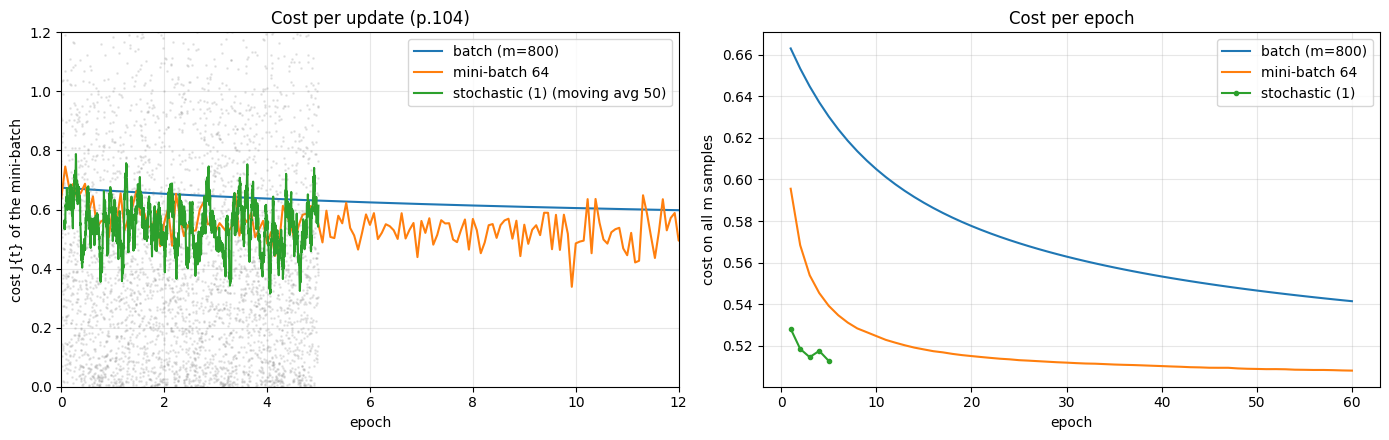

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, (c_step, c_epoch, epochs) in runs.items():
    per_epoch = len(c_step) / epochs
    x = np.arange(len(c_step)) / per_epoch                     # แกน x หน่วย epoch
    if per_epoch > 100:                                        # stochastic: จุดจางๆ + moving average
        axes[0].plot(x, c_step, ".", ms=2, alpha=0.15, color="gray")
        axes[0].plot(x[49:], np.convolve(c_step, np.ones(50) / 50, mode="valid"), label=f"{name} (moving avg 50)")
    else:
        axes[0].plot(x, c_step, label=name)
    axes[1].plot(np.arange(1, epochs + 1), c_epoch, marker="." if epochs < 10 else None, label=name)
axes[0].set_xlim(0, 12); axes[0].set_ylim(0, 1.2); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cost J{t} of the mini-batch"); axes[0].set_title("Cost per update (p.104)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cost on all m samples"); axes[1].set_title("Cost per epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### เลือกขนาด mini-batch (สไลด์ p.105-106)
| | batch ($=m$) | mini-batch | stochastic ($=1$) |
|---|---|---|---|
| ความเร็ว (p.105) | ช้ามาก: 1 อัปเดต/epoch | เร็ว: หลายอัปเดต/epoch **และ** ยังใช้ vectorization | ช้า: vectorize ไม่ได้เลย — ดูคอลัมน์ time / epoch ในตาราง |
| ลู่เข้า minimum | รับประกัน (cost ลงทุกก้าว) | ไม่รับประกัน — แกว่งรอบ minimum | ไม่รับประกัน — แกว่งมาก |

กติกา p.106: ถ้า $m \le 2000$ ใช้ batch gradient descent ไปเลย (นี่คือเหตุผลที่ lab05-08 ใช้ batch — moons มี 400 จุด, breast cancer 456)
ถ้าใหญ่กว่านั้นใช้ mini-batch ขนาดกำลังของ 2 (64, 128, 256, 512) ให้พอดี memory ของ CPU/GPU และ mini-batch ยังช่วยหนี local minimum ตื้นๆ ได้ด้วยเพราะ gradient มี noise
`NeuralNetwork(batch_size=64)` ทำ loop เดียวกับ `train_minibatch` — cell ถัดไปพิสูจน์ว่าเริ่มจาก seed เดียวกันแล้วได้ parameter เท่ากันทุกหลัก

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

In [7]:
from nnlab.nn import NeuralNetwork

params_inline, _, c_epoch_inline = train_minibatch(X_deck_c, Y_c, [6, 16, 1], GD(lr=0.05), epochs=60, batch_size=64)
model_mb = NeuralNetwork([6, 16, 1], lr=0.05, epochs=60, batch_size=64).fit(X_tr_c, y_tr_c)    # รับ X (m, n_x) แล้ว to_deck เอง
for k in params_inline:
    assert np.allclose(model_mb.params_[k], params_inline[k]), k
assert np.allclose(model_mb.history_["cost"], c_epoch_inline)
print("NeuralNetwork(batch_size=64) == train_minibatch ของเรา: parameter และ cost ต่อ epoch เท่ากันทุกหลัก ✓")
print(f"val accuracy = {model_mb.evaluate(X_te_c, y_te_c)['accuracy']:.3f}")

NeuralNetwork(batch_size=64) == train_minibatch ของเรา: parameter และ cost ต่อ epoch เท่ากันทุกหลัก ✓
val accuracy = 0.760


## ขั้นที่ 3 · optimizers: momentum, RMSprop, Adam (สไลด์ p.107-113)
กลับไปดู contour วงรีของขั้นที่ 1 อีกครั้ง (p.108): gradient descent เด้งไปมาในแกนชัน (เสียก้าวเปล่า) และคืบช้าในแกนแบน
เราอยากได้ optimizer ที่ "ไปเร็วในทิศที่ควรไป ช้าในทิศที่แกว่ง" — สามวิธีในสไลด์แก้คนละมุม (ทุกตัวคำนวณ $dW, db$ จาก mini-batch ก่อนเหมือนเดิม)

| optimizer | สูตร (p.109, 111, 113) | ความคิด |
|---|---|---|
| Momentum | $v := \beta v + (1-\beta)\,dW$; $W := W - \alpha v$ | $v$ = ค่าเฉลี่ยถ่วงน้ำหนักของ gradient ที่ผ่านมา (ลูกบอลกลิ้งในชาม p.109) — ทิศที่สลับบวก/ลบหักล้างกันเอง ทิศที่คงที่สะสมความเร็ว |
| RMSprop | $s := \beta s + (1-\beta)\,dW^2$; $W := W - \alpha\, dW / (\sqrt{s} + \varepsilon)$ | หาร gradient ด้วยขนาดเฉลี่ยของมัน — แกนที่ gradient ใหญ่ (ชัน) ถูกหดก้าว แกนแบนถูกขยาย จึงใช้ $\alpha$ ใหญ่ได้ (p.111) |
| Adam | ทั้งสองอย่าง + bias correction $\hat v = v/(1-\beta_1^t)$, $\hat s = s/(1-\beta_2^t)$; $W := W - \alpha \hat v/(\sqrt{\hat s} + \varepsilon)$ | "ใช้ได้ดีในงาน deep learning แทบทุกแบบ" (p.113) ค่าแนะนำ p.114: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$, $\alpha$ ต้อง tune |

($dW^2$ และ $\sqrt{s}$ ทำ**ทีละช่อง** — elementwise ไม่ใช่ matrix power) · $v, s$ มี shape เท่า $dW$ (p.110 note) และเริ่มจากศูนย์ทั้งหมด
cell นี้เขียนทั้งสามเป็น class ที่มี `step(params, grads)` เหมือน `GD` แล้วปล่อยทั้งสี่ตัวลงชาม $f(w) = \frac{1}{2}(w_1^2 + 20 w_2^2)$ (ชันในแกน $w_2$ 20 เท่า — ตัวแทนของ contour วงรี) จากจุดเดียวกัน 60 ก้าว

optimizer                       f หลัง 20 ก้าว    40 ก้าว    60 ก้าว
gradient descent (lr=0.09)              0.7389     0.0169    0.00039
momentum (lr=0.09, β=0.9)               2.8978     0.5630    0.01577
RMSprop (lr=0.3, β=0.9)                 1.1172     0.0009    0.00087
Adam (lr=0.3)                           3.1958     0.2156    0.08171


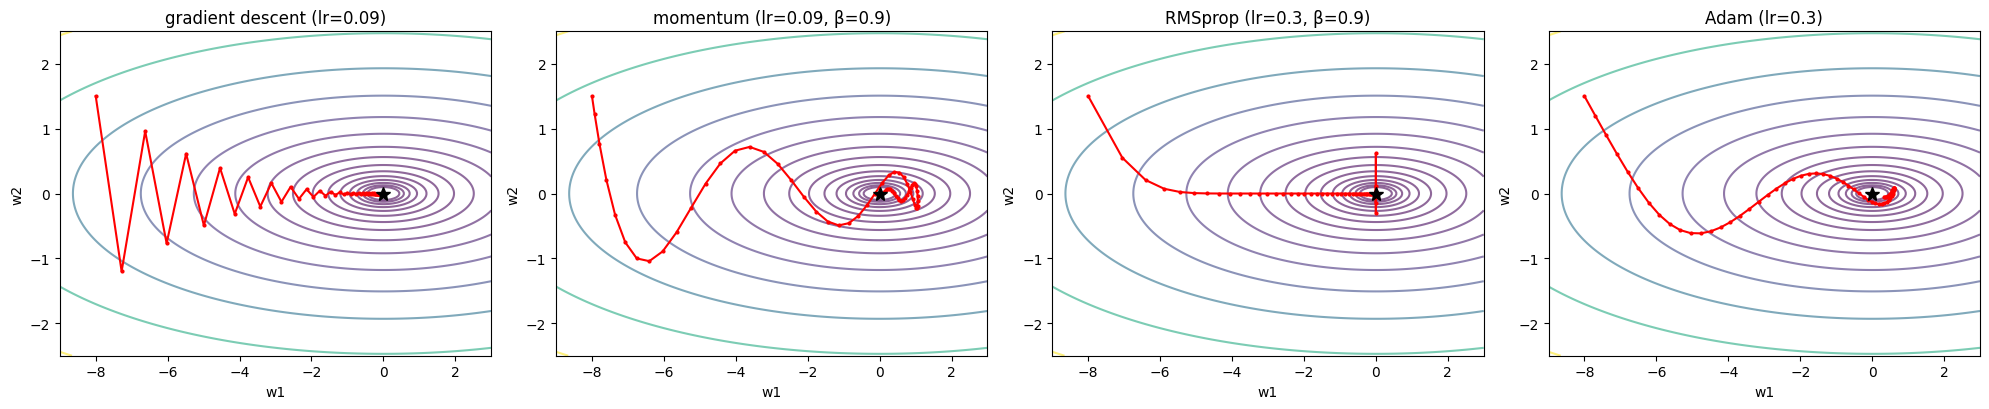

In [8]:
class Momentum:
    """v := βv + (1−β)dθ ; θ := θ − αv   (p.109-110)"""
    def __init__(self, lr, beta=0.9): self.lr, self.beta, self.v = lr, beta, {}
    def step(self, params, grads):
        for k in params:
            g = grads["d" + k]
            self.v[k] = self.beta * self.v.get(k, 0.0) + (1 - self.beta) * g      # v: shape เท่า dθ
            params[k] -= self.lr * self.v[k]

class RMSprop:
    """s := βs + (1−β)dθ² ; θ := θ − α dθ / (√s + ε)   (p.111)"""
    def __init__(self, lr, beta=0.9, eps=1e-8): self.lr, self.beta, self.eps, self.s = lr, beta, eps, {}
    def step(self, params, grads):
        for k in params:
            g = grads["d" + k]
            self.s[k] = self.beta * self.s.get(k, 0.0) + (1 - self.beta) * g ** 2   # g ** 2 = elementwise
            params[k] -= self.lr * g / (np.sqrt(self.s[k]) + self.eps)

class Adam:
    """momentum + RMSprop + bias correction   (p.113)  ค่า default ตาม p.114"""
    def __init__(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.v, self.s, self.t = {}, {}, 0
    def step(self, params, grads):
        self.t += 1                                                            # นับก้าว t ใช้ใน bias correction
        for k in params:
            g = grads["d" + k]
            self.v[k] = self.beta1 * self.v.get(k, 0.0) + (1 - self.beta1) * g
            self.s[k] = self.beta2 * self.s.get(k, 0.0) + (1 - self.beta2) * g ** 2
            v_hat = self.v[k] / (1 - self.beta1 ** self.t)                    # bias correction (p.112)
            s_hat = self.s[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * v_hat / (np.sqrt(s_hat) + self.eps)

def bowl(w):  return 0.5 * (w[0] ** 2 + 20 * w[1] ** 2)     # f(w1, w2)
def dbowl(w): return np.array([w[0], 20 * w[1]])            # ∇f = [w1, 20 w2]

def run_bowl(optimizer, steps=60, w0=(-8.0, 1.5)):
    params = {"w": np.array(w0, dtype=float)}; path = [params["w"].copy()]
    for _ in range(steps):
        optimizer.step(params, {"dw": dbowl(params["w"])}); path.append(params["w"].copy())
    return np.array(path)                                   # (steps+1, 2)

optimizers = {"gradient descent (lr=0.09)": GD(lr=0.09), "momentum (lr=0.09, β=0.9)": Momentum(lr=0.09, beta=0.9),
              "RMSprop (lr=0.3, β=0.9)": RMSprop(lr=0.3, beta=0.9), "Adam (lr=0.3)": Adam(lr=0.3)}
paths = {name: run_bowl(opt) for name, opt in optimizers.items()}
print(f"{'optimizer':<30} {'f หลัง 20 ก้าว':>15} {'40 ก้าว':>10} {'60 ก้าว':>10}")
for name, p in paths.items():
    f = np.array([bowl(w) for w in p])
    print(f"{name:<30} {f[20]:>15.4f} {f[40]:>10.4f} {f[60]:>10.5f}")

g1, g2 = np.meshgrid(np.linspace(-9, 3, 200), np.linspace(-2.5, 2.5, 200))
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, (name, p) in zip(axes, paths.items()):
    ax.contour(g1, g2, 0.5 * (g1 ** 2 + 20 * g2 ** 2), levels=np.logspace(-1, 2, 15), alpha=0.6)
    ax.plot(p[:, 0], p[:, 1], "r.-", ms=4); ax.plot(0, 0, "k*", ms=10); ax.set_title(name); ax.set_xlabel("w1"); ax.set_ylabel("w2")
plt.tight_layout(); plt.show()

อ่านรูป (p.108): gradient descent ที่ $\alpha = 0.09$ เด้งขึ้นลงในแกน $w_2$ (ชัน) แล้วคืบช้าในแกน $w_1$; momentum ทำให้การเด้งหักล้างกันจนเป็นโค้งเรียบและวิ่งเร็วขึ้นในแกน $w_1$ (แต่เลยเป้าไปหน่อยเพราะมี "ความเร็ว" สะสม)
RMSprop หดก้าวในแกน $w_2$ ที่ gradient ใหญ่ จึงใช้ $\alpha$ ใหญ่กว่า 3 เท่าได้โดยไม่เด้ง; Adam ได้ทั้งสองอย่าง — สังเกตว่า Adam ก้าวราวๆ $\alpha$ ต่อก้าวในทุกแกนช่วงแรก (เพราะ $\hat v / \sqrt{\hat s} \approx \pm 1$) จึงเดินตรงและสม่ำเสมอ

### bias correction ทำงานอย่างไร (สไลด์ p.112)
$v_t = \beta v_{t-1} + (1-\beta)\theta_t$ โดย $v_0 = 0$ ทำให้ $v_1 = (1-\beta)\theta_1$ เล็กกว่า $\theta_1$ มาก (ที่ $\beta = 0.98$ ได้แค่ $0.02\theta_1$) — ช่วงแรกค่าเฉลี่ยจึง "เอนไปทางศูนย์"
หารด้วย $1 - \beta^t$ แก้ได้พอดี: $v_1 / (1 - 0.98) = \theta_1$ และ $v_2 = 0.0196\theta_1 + 0.02\theta_2$ หารด้วย $1 - 0.98^2 = 0.0396$ = ค่าเฉลี่ยถ่วงน้ำหนักของ $\theta_1, \theta_2$ ที่น้ำหนักรวมเป็น 1
พอ $t$ ใหญ่ $\beta^t \to 0$ ตัวหารเข้าใกล้ 1 — correction หมดผลไปเอง cell นี้ทำซ้ำตัวเลขของสไลด์ด้วย $\theta_t = 1$ ทุกตัว (ค่าเฉลี่ยที่ถูกต้องคือ 1) และกับ $\theta_t$ สุ่ม

In [9]:
beta = 0.98
print(f"{'t':>3} | {'v_t':>8} | {'1 - β^t':>8} | {'v_t/(1-β^t)':>12}    (θ_t = 1 ทุกตัว → ค่าเฉลี่ยที่ถูกต้อง = 1)")
v = 0.0
for t in range(1, 11):
    v = beta * v + (1 - beta) * 1.0                          # v_1 = 0.02, v_2 = 0.0196 + 0.02 = 0.0396, ...
    print(f"{t:>3} | {v:>8.4f} | {1 - beta ** t:>8.4f} | {v / (1 - beta ** t):>12.4f}")
print("→ v_t ตรงๆ ใช้เวลานานกว่าจะเข้าใกล้ 1 แต่ v_t/(1−β^t) ให้ 1 ตั้งแต่ก้าวแรก (p.112) ✓")

theta = rng.standard_normal(200) + 3.0                      # θ_t สุ่มรอบค่าเฉลี่ย 3
v, raw, corrected = 0.0, [], []
for t, th in enumerate(theta, start=1):
    v = beta * v + (1 - beta) * th
    raw.append(v); corrected.append(v / (1 - beta ** t))
print(f"θ สุ่ม mean 3: หลัง 10 ก้าว v = {raw[9]:.3f} (เล็กเกินจริง) | corrected = {corrected[9]:.3f} | หลัง 200 ก้าว v = {raw[-1]:.3f} ≈ corrected = {corrected[-1]:.3f}")

  t |      v_t |  1 - β^t |  v_t/(1-β^t)    (θ_t = 1 ทุกตัว → ค่าเฉลี่ยที่ถูกต้อง = 1)
  1 |   0.0200 |   0.0200 |       1.0000
  2 |   0.0396 |   0.0396 |       1.0000
  3 |   0.0588 |   0.0588 |       1.0000
  4 |   0.0776 |   0.0776 |       1.0000
  5 |   0.0961 |   0.0961 |       1.0000
  6 |   0.1142 |   0.1142 |       1.0000
  7 |   0.1319 |   0.1319 |       1.0000
  8 |   0.1492 |   0.1492 |       1.0000
  9 |   0.1663 |   0.1663 |       1.0000
 10 |   0.1829 |   0.1829 |       1.0000
→ v_t ตรงๆ ใช้เวลานานกว่าจะเข้าใกล้ 1 แต่ v_t/(1−β^t) ให้ 1 ตั้งแต่ก้าวแรก (p.112) ✓
θ สุ่ม mean 3: หลัง 10 ก้าว v = 0.507 (เล็กเกินจริง) | corrected = 2.769 | หลัง 200 ก้าว v = 3.015 ≈ corrected = 3.069


## ขั้นที่ 4 · numpy | torch เทียบทีละก้าว
optimizer ไม่เกี่ยวกับ layout ของ $X$ เลย — รับ parameter กับ gradient แล้วอัปเดต — จึงเทียบกันตรงๆ ได้
เราสร้าง **ลำดับ gradient คงที่** 10 ก้อน (สุ่มไว้ล่วงหน้า) ป้อนให้ `nnlab.optimizers` ฝั่ง numpy และ `torch.optim` ฝั่ง torch (ตั้ง `.grad` ด้วยมือแล้ว `step()`) จากค่าเริ่มต้นเดียวกัน แล้วดูว่า parameter สุดท้ายเท่ากันไหม
- `Adam` ↔ `torch.optim.Adam` : สูตรเดียวกันทุกบรรทัด (รวม bias correction) → ต้องเท่ากันระดับ $10^{-6}$ หรือดีกว่า
- `RMSProp(beta=0.99)` ↔ `torch.optim.RMSprop(alpha=0.99)` : torch เรียก $\beta$ ว่า `alpha` → เท่ากัน
- `Momentum(beta=0.9)` ↔ `torch.optim.SGD(momentum=0.9)` : torch ใช้ $v := \beta v + dW$ **ไม่มี** $(1-\beta)$ (p.110 "some literature omitted $1-\beta$") → $v$ ของ torch ใหญ่กว่า $\frac{1}{1-\beta} = 10$ เท่า → ต้องตั้ง `lr` ของ torch เป็น $(1-\beta)\alpha$ ถึงจะเท่ากัน

In [10]:
from nnlab import optimizers as nnopt

grad_seq = [rng.standard_normal((3, 2)) for _ in range(10)]       # gradient คงที่ 10 ก้าว shape (3, 2)
W0 = rng.standard_normal((3, 2))

def run_numpy(opt):
    params = {"W": W0.copy()}
    for g in grad_seq:
        opt.step(params, {"dW": g})
    return params["W"]

def run_torch(make_opt):
    w = torch.nn.Parameter(torch.tensor(W0))                      # float64 เหมือน numpy
    opt = make_opt(w)
    for g in grad_seq:
        opt.zero_grad(); w.grad = torch.tensor(g); opt.step()     # ใส่ gradient เอง แทนที่จะ loss.backward()
    return w.detach().numpy()

pairs = [
    ("Adam lr=0.1",                    nnopt.Adam(lr=0.1),                 lambda w: torch.optim.Adam([w], lr=0.1)),
    ("RMSProp lr=0.01 β=0.99",         nnopt.RMSProp(lr=0.01, beta=0.99),  lambda w: torch.optim.RMSprop([w], lr=0.01, alpha=0.99)),
    ("Momentum lr=0.1 β=0.9 (ตรงๆ)",   nnopt.Momentum(lr=0.1, beta=0.9),   lambda w: torch.optim.SGD([w], lr=0.1, momentum=0.9)),
    ("Momentum vs SGD lr=(1−β)·0.1",  nnopt.Momentum(lr=0.1, beta=0.9),   lambda w: torch.optim.SGD([w], lr=0.1 * (1 - 0.9), momentum=0.9)),
]
for name, np_opt, mk in pairs:
    diff = np.abs(run_numpy(np_opt) - run_torch(mk)).max()
    print(f"{name:<32} max |numpy − torch| = {diff:.2e}  {'✓ เท่ากัน' if diff < 1e-6 else '✗ ต่างกัน (ตัวคูณ 1−β)'}")
assert np.abs(run_numpy(nnopt.Adam(lr=0.1)) - run_torch(lambda w: torch.optim.Adam([w], lr=0.1))).max() < 1e-6

Adam lr=0.1                      max |numpy − torch| = 1.11e-16  ✓ เท่ากัน
RMSProp lr=0.01 β=0.99           max |numpy − torch| = 0.00e+00  ✓ เท่ากัน
Momentum lr=0.1 β=0.9 (ตรงๆ)     max |numpy − torch| = 1.60e+00  ✗ ต่างกัน (ตัวคูณ 1−β)
Momentum vs SGD lr=(1−β)·0.1     max |numpy − torch| = 1.11e-16  ✓ เท่ากัน


## ขั้นที่ 5 · optimizer กับข้อมูลจริง: breast cancer
`NeuralNetwork(optimizer=...)` รับชื่อ `'sgd' | 'momentum' | 'rmsprop' | 'adam'` (สร้าง object จาก `nnlab.optimizers` ให้) และใช้ loop เดียวกับ `train_minibatch`
ข้อมูล breast cancer มี 30 feature (normalize แล้ว), train 456 / test 113 — เทรน `[30, 16, 1]` 100 epoch mini-batch 32 ด้วย optimizer ทั้งสี่
learning rate ใช้ค่าที่นิยม: 0.01 สำหรับ sgd/momentum และ 0.001 สำหรับ rmsprop/adam (ที่ปรับ scale ก้าวเองแล้ว) — คาดว่า cost ของ adam/rmsprop จะลงเร็วกว่ามาก ส่วน accuracy บน test set 113 ตัวจะใกล้กันหมด (ต่างกัน 1 ตัว = 0.9%)

breast cancer: train (456, 30) test (113, 30) | malignant rate = 0.373


optimizer    lr  cost @10  cost @100  train acc  test acc  time (s)
      sgd 0.010    0.2133     0.0701     0.9825    0.9646    0.0553
 momentum 0.010    0.2120     0.0703     0.9825    0.9646    0.0694
  rmsprop 0.001    0.0453     0.0091     0.9978    0.9292    0.0824
     adam 0.001    0.1489     0.0272     0.9934    0.9292    0.0965


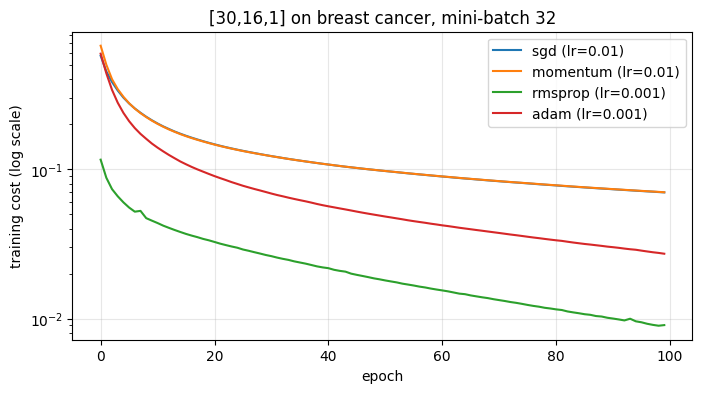

In [11]:
from nnlab.data import load_breast_cancer_scaled

Xb_tr, Xb_te, yb_tr, yb_te = load_breast_cancer_scaled()          # (456, 30) / (113, 30) normalize ด้วย μ,σ ของ train
print("breast cancer: train", Xb_tr.shape, "test", Xb_te.shape, "| malignant rate =", round(yb_tr.mean(), 3))

opt_models, rows = {}, []
for opt_name, lr_i in [("sgd", 0.01), ("momentum", 0.01), ("rmsprop", 0.001), ("adam", 0.001)]:
    with Timer() as t:
        model = NeuralNetwork([30, 16, 1], lr=lr_i, epochs=100, batch_size=32, optimizer=opt_name).fit(Xb_tr, yb_tr)
    opt_models[opt_name] = model
    rows.append({"optimizer": opt_name, "lr": lr_i, "cost @10": model.history_["cost"][9], "cost @100": model.history_["cost"][-1],
                 "train acc": model.evaluate(Xb_tr, yb_tr)["accuracy"], "test acc": model.evaluate(Xb_te, yb_te)["accuracy"], "time (s)": t.elapsed})
opt_table = pd.DataFrame(rows).round(4)
print(opt_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
for opt_name, model in opt_models.items():
    ax.plot(model.history_["cost"], label=f"{opt_name} (lr={dict(zip(opt_table['optimizer'], opt_table['lr']))[opt_name]})")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("training cost (log scale)"); ax.set_title("[30,16,1] on breast cancer, mini-batch 32"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## ขั้นที่ 6 · learning rate decay และเครื่องมือของ torch (สไลด์ p.114)
mini-batch ทำให้ gradient มี noise — ช่วงท้ายจึงวนอยู่รอบ minimum ด้วยรัศมีประมาณ $\alpha \times$ noise (p.114 ซ้าย "fixed learning rate")
**learning rate decay** ค่อยๆ ลด $\alpha$ ตาม epoch ให้ก้าวเล็กลงเมื่อใกล้ถึง: $\alpha = \dfrac{\alpha_0}{1 + \text{decay\_rate} \times \text{epoch}}$ (`nnlab.optimizers.lr_decay`)
cell นี้วาดสูตรที่ decay_rate ต่างกัน แล้วใช้ `train_minibatch` (ผ่าน `lr_schedule`) เทรน sgd บน breast cancer ด้วย $\alpha$ คงที่ 0.05 เทียบกับ decay จาก 0.05 — ดูว่า cost ช่วงท้ายนิ่งกว่าไหม

lr ที่ epoch 0, 10, 50, 99 (decay_rate 0.05): [0.05, 0.0333, 0.0143, 0.0084]


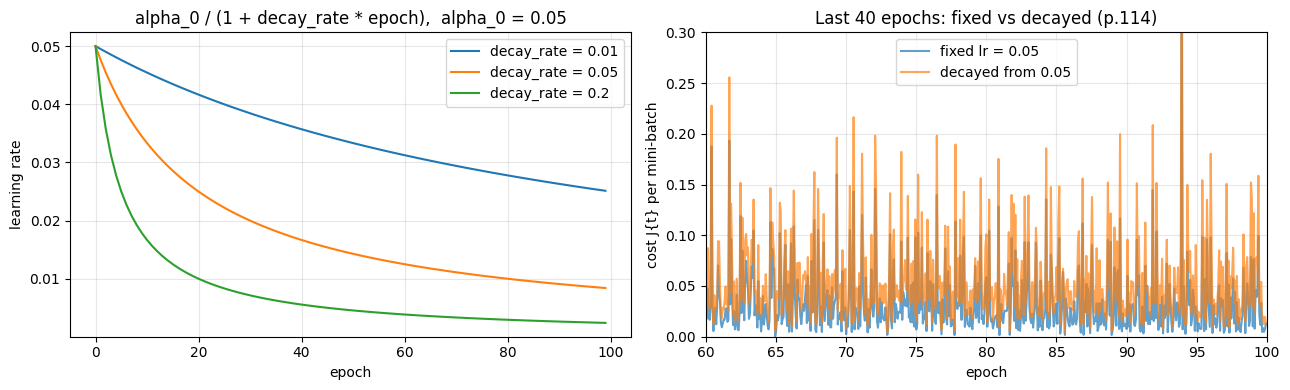

ความแกว่งของ J{t} ใน 20 epoch สุดท้าย (std): fixed 0.0321 | decayed 0.0473
cost ทั้ง training set epoch สุดท้าย: fixed 0.0289 | decayed 0.0521


In [12]:
from nnlab.optimizers import lr_decay, SGD

epochs_axis = np.arange(100)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for rate in [0.01, 0.05, 0.2]:
    axes[0].plot(epochs_axis, [lr_decay(0.05, e, rate) for e in epochs_axis], label=f"decay_rate = {rate}")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("learning rate"); axes[0].set_title("alpha_0 / (1 + decay_rate * epoch),  alpha_0 = 0.05"); axes[0].legend(); axes[0].grid(alpha=0.3)
print("lr ที่ epoch 0, 10, 50, 99 (decay_rate 0.05):", [round(lr_decay(0.05, e, 0.05), 4) for e in [0, 10, 50, 99]])

Xb_deck, Yb = to_deck(Xb_tr, yb_tr)                                    # (30, 456), (1, 456)
_, c_fixed, e_fixed = train_minibatch(Xb_deck, Yb, [30, 16, 1], SGD(lr=0.05), epochs=100, batch_size=32)
_, c_decay, e_decay = train_minibatch(Xb_deck, Yb, [30, 16, 1], SGD(lr=0.05), epochs=100, batch_size=32, lr_schedule=lambda e: lr_decay(0.05, e, 0.05))
per_epoch = len(c_fixed) // 100
for c, name in [(c_fixed, "fixed lr = 0.05"), (c_decay, "decayed from 0.05")]:
    axes[1].plot(np.arange(len(c)) / per_epoch, c, alpha=0.7, label=name)
axes[1].set_xlim(60, 100); axes[1].set_ylim(0, 0.3); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cost J{t} per mini-batch"); axes[1].set_title("Last 40 epochs: fixed vs decayed (p.114)"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"ความแกว่งของ J{{t}} ใน 20 epoch สุดท้าย (std): fixed {c_fixed[-20 * per_epoch:].std():.4f} | decayed {c_decay[-20 * per_epoch:].std():.4f}")
print(f"cost ทั้ง training set epoch สุดท้าย: fixed {e_fixed[-1]:.4f} | decayed {e_decay[-1]:.4f}")

### torch: `TensorDataset` + `DataLoader` = `iterate_minibatches` และ `TorchTrainer(optimizer='adam')`
ฝั่ง torch การหั่น mini-batch เป็นหน้าที่ของ `DataLoader`: ห่อ tensor ด้วย `TensorDataset` แล้วสั่ง `batch_size=64, shuffle=True` มันจะสับลำดับทุก epoch และคืนทีละก้อน (ก้อนสุดท้ายเล็กกว่าเหมือนที่เราหั่นเอง)
sample เป็น **แถว** ตาม library convention — mini-batch จึงเป็น `(64, n_x)` ไม่ใช่ `(n_x, 64)`
`TorchTrainer` (lab07) ใช้ loop `zero_grad → forward → loss → backward → step` กับ `DataLoader` นี้ และ `optimizer="adam"` คือ `torch.optim.Adam` ที่เราเพิ่งพิสูจน์ว่าตรงกับ `nnlab.optimizers.Adam`

In [13]:
from torch.utils.data import TensorDataset, DataLoader
from nnlab.torch_models import TorchMLP, TorchTrainer

ds = TensorDataset(torch.tensor(Xb_tr, dtype=torch.float32), torch.tensor(yb_tr, dtype=torch.float32))   # 456 คู่ (x, y)
loader = DataLoader(ds, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(463))
for t, (xb, yb) in enumerate(loader, start=1):
    if t <= 2 or t == len(loader):
        print(f"batch t={t:>2}: x {tuple(xb.shape)}  y {tuple(yb.shape)}   ← sample เป็นแถว (64, 30)")
print(f"รวม {len(loader)} batch ต่อ epoch (ceil(456/64) = 8)\n")

with Timer() as t_torch:
    trainer = TorchTrainer(TorchMLP([30, 16, 1]), loss="bce", optimizer="adam", lr=0.001, epochs=100, batch_size=32, device="cpu").fit(Xb_tr, yb_tr)
print(f"TorchTrainer adam: cost @100 = {trainer.history_['cost'][-1]:.4f} | test acc = {trainer.evaluate(Xb_te, yb_te)['accuracy']:.4f} | {t_torch.elapsed:.1f}s")
print(f"numpy NeuralNetwork adam: cost @100 = {opt_models['adam'].history_['cost'][-1]:.4f} | test acc = {opt_models['adam'].evaluate(Xb_te, yb_te)['accuracy']:.4f}")
print("(ต่างกันเล็กน้อยเพราะค่าเริ่มต้นและลำดับ mini-batch ของ torch ไม่เหมือน numpy — สูตร optimizer เหมือนกัน)")

batch t= 1: x (64, 30)  y (64,)   ← sample เป็นแถว (64, 30)
batch t= 2: x (64, 30)  y (64,)   ← sample เป็นแถว (64, 30)
batch t= 8: x (8, 30)  y (8,)   ← sample เป็นแถว (64, 30)
รวม 8 batch ต่อ epoch (ceil(456/64) = 8)



TorchTrainer adam: cost @100 = 0.0258 | test acc = 0.9469 | 0.3s
numpy NeuralNetwork adam: cost @100 = 0.0272 | test acc = 0.9292
(ต่างกันเล็กน้อยเพราะค่าเริ่มต้นและลำดับ mini-batch ของ torch ไม่เหมือน numpy — สูตร optimizer เหมือนกัน)


## ขั้นที่ 7 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/optimizers.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (`SGD` / `Momentum` / `RMSProp` / `Adam` ที่ `NeuralNetwork` ใช้ผ่าน `optimizer=`) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/optimizers.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [14]:
# 1) class ที่เขียนเองในขั้นที่ 3 vs nnlab.optimizers บนชามเดียวกัน → path เท่ากันทุกก้าว
for name, mine, lib in [("Momentum", Momentum(lr=0.09, beta=0.9), nnopt.Momentum(lr=0.09, beta=0.9)),
                        ("RMSprop", RMSprop(lr=0.3, beta=0.9), nnopt.RMSProp(lr=0.3, beta=0.9)),
                        ("Adam", Adam(lr=0.3), nnopt.Adam(lr=0.3)),
                        ("GD/SGD", GD(lr=0.09), nnopt.SGD(lr=0.09))]:
    assert np.allclose(run_bowl(mine), run_bowl(lib)), name
    print(f"{name:<9} path ของเรา == path ของ nnlab.optimizers ✓   ({lib!r})")

# 2) NeuralNetwork(optimizer='adam', batch_size=32) == train_minibatch + nnlab Adam จาก seed เดียวกัน
params_adam, _, e_adam = train_minibatch(Xb_deck, Yb, [30, 16, 1], nnopt.Adam(lr=0.001), epochs=100, batch_size=32)
lib_adam = opt_models["adam"]
for k in params_adam:
    assert np.allclose(lib_adam.params_[k], params_adam[k]), k
assert np.allclose(lib_adam.history_["cost"], e_adam)
print("\nNeuralNetwork(optimizer='adam') ให้ parameter และ cost ต่อ epoch เท่ากับ train_minibatch ของเรา ✓")
print(lib_adam)

Momentum  path ของเรา == path ของ nnlab.optimizers ✓   (Momentum(lr=0.09, beta=0.9))
RMSprop   path ของเรา == path ของ nnlab.optimizers ✓   (RMSProp(lr=0.3, beta=0.9, eps=1e-08))
Adam      path ของเรา == path ของ nnlab.optimizers ✓   (Adam(lr=0.3, beta1=0.9, beta2=0.999, eps=1e-08))
GD/SGD    path ของเรา == path ของ nnlab.optimizers ✓   (SGD(lr=0.09))

NeuralNetwork(optimizer='adam') ให้ parameter และ cost ต่อ epoch เท่ากับ train_minibatch ของเรา ✓
NeuralNetwork(layer_sizes=[30, 16, 1], activations=['relu', 'sigmoid'], lr=0.001, epochs=100, optimizer=Adam(lr=0.001, beta1=0.9, beta2=0.999, eps=1e-08))


## ★ Key Takeaways
- normalize input ทีละ feature ด้วย $\mu, \sigma$ ของ training set (หาร $\sigma$ ไม่ใช่ $\sigma^2$) แล้วใช้ค่าเดิมกับ test — contour กลมขึ้น ใช้ learning rate ใหญ่ขึ้นและถึงเร็วขึ้นหลายเท่า
- mini-batch: สับ index ด้วย permutation แล้วหั่น $X$ เป็นก้อนละ `batch_size` คอลัมน์ อัปเดตทุกก้อน — cost $\mathcal{J}^{\{t\}}$ แกว่งเป็นเรื่องปกติ ให้ดู cost ทั้ง training set ต่อ epoch
- กติกา p.105-106: $m \le 2000$ ใช้ batch; ใหญ่กว่านั้นใช้ mini-batch 64-512 (กำลังของ 2); batch_size = 1 ช้าเพราะเสีย vectorization
- momentum เฉลี่ย gradient (หักล้างการเด้ง), RMSprop หารด้วยขนาด gradient (ใช้ $\alpha$ ใหญ่ได้), Adam รวมทั้งสอง + bias correction $v/(1-\beta^t)$; ใช้ $\beta_1 = 0.9, \beta_2 = 0.999, \varepsilon = 10^{-8}$ แล้ว tune แค่ $\alpha$
- `nnlab.optimizers.Adam/RMSProp` ตรงกับ `torch.optim.Adam/RMSprop` ทุกก้าว แต่ `torch.optim.SGD(momentum=β)` ไม่มี $(1-\beta)$ — ต้องคูณ lr ด้วย $(1-\beta)$ ถึงจะเท่ากัน (p.110)
- learning rate decay $\alpha_0/(1 + \text{decay\_rate}\cdot\text{epoch})$ ลดการแกว่งช่วงท้ายของ mini-batch; ใน torch `DataLoader(shuffle=True)` คือ `iterate_minibatches` และ `TorchTrainer(optimizer='adam')` คือ loop เดียวกับ `NeuralNetwork`

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [15]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 9.1 · หนึ่งก้าวของ momentum เป็นฟังก์ชัน
**เป้าหมาย:** เขียน `momentum_step(w, dw, v, lr, beta)` ที่ทำสูตร p.109 หนึ่งก้าวแล้วคืน (w ใหม่, v ใหม่) โดยไม่แก้ array เดิม

**ขั้นตอน**
1. คำนวณ velocity ใหม่จาก v เก่าและ gradient: `v_new = beta * v + (1 - beta) * dw` (shape เท่า dw)
2. ก้าวด้วย velocity (ไม่ใช่ gradient ตรงๆ): `w_new = w - lr * v_new`
3. คืน `(w_new, v_new)` — ผู้เรียกจะส่ง `v_new` กลับเข้ามาเป็น `v` ในก้าวถัดไป (นี่คือสิ่งที่ `self.v[k]` เก็บไว้ใน class `Momentum` ของขั้นที่ 3)
4. cell ตรวจจะเรียกต่อกันหลายก้าวแล้วเทียบกับ `nnlab.optimizers.Momentum` และเทียบ β=0 กับ `nnlab.optimizers.SGD`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- สองบรรทัดจากตาราง p.109: `v_new = beta * v + (1 - beta) * dw` และ `w_new = w - lr * v_new`
- `w - lr * v_new` สร้าง array ใหม่ ส่วน `w -= ...` แก้ของเดิม — ข้อนี้ต้องการแบบแรก
</details>

In [16]:
# --- แบบฝึกหัด 9.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def momentum_step(w, dw, v, lr, beta=0.9):
    """momentum หนึ่งก้าว (p.109): คืน (w_new, v_new)   w, dw, v: shape เดียวกัน   v ก้าวแรกคือ np.zeros_like(w)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: w1, v1 = momentum_step(np.array([1.0, 2.0]), np.array([0.5, -0.5]), np.zeros(2), lr=0.1); print(w1, v1)

In [17]:
# --- ตรวจคำตอบ 9.1 (รันได้ทันที ไม่ต้องแก้) ---
w0_91 = np.array([[1.0, -2.0], [0.5, 3.0]])
g1_91, g2_91 = np.array([[0.2, -0.4], [1.0, 0.1]]), np.array([[-0.3, 0.2], [0.5, -1.0]])

def _ref_91(grads, beta=0.9):                            # อ้างอิง: nnlab.optimizers.Momentum (หรือ SGD เมื่อ beta=None) ก้าวตามลำดับ grads
    opt = nnopt.SGD(lr=0.1) if beta is None else nnopt.Momentum(lr=0.1, beta=beta)
    p = {"w": w0_91.copy()}
    for g in grads:
        opt.step(p, {"dw": g})
    return p["w"]

def _mine_91(grads, beta=0.9):                           # เรียกฟังก์ชันของนิสิตต่อกัน ส่ง v กลับเข้าไป
    w, v = w0_91, np.zeros_like(w0_91)
    for g in grads:
        w, v = momentum_step(w, g, v, 0.1, beta)
    return w

def _no_inplace_91():
    w, v = w0_91.copy(), np.zeros_like(w0_91)
    momentum_step(w, g1_91, v, 0.1, 0.9)
    return np.array_equal(w, w0_91) and np.all(v == 0)

check_shape("9.1 w_new shape เท่า w", lambda: momentum_step(w0_91, g1_91, np.zeros_like(w0_91), 0.1, 0.9)[0], (2, 2))
check_close("9.1 ก้าวแรกตรงกับ nnlab.optimizers.Momentum", lambda: _mine_91([g1_91]), _ref_91([g1_91]), hint="v เริ่มจาก 0 → ก้าวแรก v_new = (1−β)·dw แล้ว w_new = w − lr·v_new")
check_close("9.1 สามก้าวต่อกัน (ส่ง v กลับเข้าไป)", lambda: _mine_91([g1_91, g2_91, g1_91]), _ref_91([g1_91, g2_91, g1_91]), hint="ต้องคืน v_new ตัวใหม่ ไม่ใช่ v เดิม")
check_close("9.1 β=0 → เท่ากับ gradient descent ธรรมดา (nnlab SGD)", lambda: _mine_91([g1_91, g2_91], beta=0.0), _ref_91([g1_91, g2_91], beta=None), hint="ที่ β=0: v_new = dw พอดี")
check("9.1 ไม่แก้ w และ v เดิม (in-place)", _no_inplace_91, hint="ใช้ w - lr * v_new (สร้าง array ใหม่) ไม่ใช่ w -= ... หรือ v *= ...")

⏳ 9.1 w_new shape เท่า w: ยังไม่ได้ทำ
⏳ 9.1 ก้าวแรกตรงกับ nnlab.optimizers.Momentum: ยังไม่ได้ทำ
⏳ 9.1 สามก้าวต่อกัน (ส่ง v กลับเข้าไป): ยังไม่ได้ทำ
⏳ 9.1 β=0 → เท่ากับ gradient descent ธรรมดา (nnlab SGD): ยังไม่ได้ทำ
⏳ 9.1 ไม่แก้ w และ v เดิม (in-place): ยังไม่ได้ทำ


False

### แบบฝึกหัด 9.2 · หั่น mini-batch ด้วย permutation
**เป้าหมาย:** เขียน `make_minibatches(X, Y, batch_size, rng)` ที่สับลำดับ sample แล้วหั่น X (n_x, m), Y (1, m) เป็น list ของ (X{t}, Y{t}) ตาม p.102

**ขั้นตอน**
1. `m = X.shape[1]` แล้วสุ่มลำดับ `perm = rng.permutation(m)`
2. วน `start` ตั้งแต่ 0 ถึง m ทีละ `batch_size` (`range(0, m, batch_size)`) เอา `idx = perm[start:start + batch_size]`
3. เลือก**คอลัมน์** `X[:, idx]`, `Y[:, idx]` ใส่ list เป็นคู่ `(X_t, Y_t)` — ก้อนสุดท้ายเล็กกว่าได้ (800/64 → ก้อนที่ 13 มี 32)
4. คืน list — cell ตรวจจะดูจำนวนก้อน, shape, ว่า X กับ Y ยังจับคู่กันถูก และทุก sample ถูกใช้ครั้งเดียว (เหมือน cell แรกของขั้นที่ 2)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- โครงเดียวกับ loop ใน cell แรกของขั้นที่ 2 (`perm`, `idx`, `X_deck_c[:, idx]`) แต่ห่อเป็นฟังก์ชันและคืน list
- `X[:, idx]` = ทุกแถว เฉพาะคอลัมน์ใน idx (sample เป็นคอลัมน์ใน deck convention)
</details>

In [18]:
# --- แบบฝึกหัด 9.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def make_minibatches(X, Y, batch_size, rng):
    """X: (n_x, m), Y: (1, m) → list ของ (X_t (n_x, ≤batch_size), Y_t (1, ≤batch_size)) หลังสับลำดับ sample"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: bs = make_minibatches(X_deck_c, Y_c, 64, rng); print(len(bs), bs[0][0].shape, bs[-1][0].shape)

In [19]:
# --- ตรวจคำตอบ 9.2 (รันได้ทันที ไม่ต้องแก้) ---
m_92 = 100
X_92 = np.vstack([np.arange(m_92, dtype=float), rng.random((2, m_92))])   # (3, 100) แถว 0 = เลข index ของ sample
Y_92 = (np.arange(m_92) % 3 == 0).astype(float).reshape(1, -1)            # (1, 100) label ที่รู้ว่าคู่กับ index ไหน
rng_92 = np.random.default_rng(92)

def _idx_92(batches):                                                     # index ของ sample ในแต่ละก้อน (อ่านจากแถว 0 ของ X_t)
    return [np.asarray(X_t)[0].astype(int) for X_t, _ in batches]

def _aligned_92():
    batches = make_minibatches(X_92, Y_92, 32, rng_92)
    return all(np.array_equal(np.asarray(Y_t)[0], Y_92[0, np.asarray(X_t)[0].astype(int)]) for X_t, Y_t in batches)

check("9.2 จำนวนก้อน = ceil(100/32) = 4", lambda: len(make_minibatches(X_92, Y_92, 32, rng_92)) == 4, hint="range(0, m, batch_size) ให้ start = 0, 32, 64, 96")
check_shape("9.2 ก้อนแรก X_t shape (3, 32)", lambda: make_minibatches(X_92, Y_92, 32, rng_92)[0][0], (3, 32), hint="เลือกคอลัมน์: X[:, idx] ไม่ใช่ X[idx]")
check_shape("9.2 ก้อนสุดท้าย Y_t shape (1, 4)", lambda: make_minibatches(X_92, Y_92, 32, rng_92)[-1][1], (1, 4), hint="Y[:, idx] รักษามิติ (1, ·) ไว้")
check("9.2 ทุก sample ถูกใช้ครั้งเดียว", lambda: np.array_equal(np.sort(np.concatenate(_idx_92(make_minibatches(X_92, Y_92, 32, rng_92)))), np.arange(m_92)), hint="slice perm ต่อกันโดยไม่ซ้อนและไม่ข้าม")
check("9.2 ลำดับถูกสับ (ไม่ใช่ 0, 1, 2, ...)", lambda: not np.array_equal(_idx_92(make_minibatches(X_92, Y_92, 32, rng_92))[0], np.arange(32)), hint="ใช้ rng.permutation(m) ก่อน slice")
check("9.2 X กับ Y ยังจับคู่กันถูก", _aligned_92, hint="ใช้ idx ชุดเดียวกันกับทั้ง X และ Y")
check("9.2 churn (6, 800) batch 64 → 13 ก้อน ก้อนสุดท้าย (6, 32)", lambda: (lambda b: len(b) == 13 and tuple(b[-1][0].shape) == (6, 32))(make_minibatches(X_deck_c, Y_c, 64, rng_92)))

⏳ 9.2 จำนวนก้อน = ceil(100/32) = 4: ยังไม่ได้ทำ
⏳ 9.2 ก้อนแรก X_t shape (3, 32): ยังไม่ได้ทำ
⏳ 9.2 ก้อนสุดท้าย Y_t shape (1, 4): ยังไม่ได้ทำ
⏳ 9.2 ทุก sample ถูกใช้ครั้งเดียว: ยังไม่ได้ทำ
⏳ 9.2 ลำดับถูกสับ (ไม่ใช่ 0, 1, 2, ...): ยังไม่ได้ทำ
⏳ 9.2 X กับ Y ยังจับคู่กันถูก: ยังไม่ได้ทำ
⏳ 9.2 churn (6, 800) batch 64 → 13 ก้อน ก้อนสุดท้าย (6, 32): ยังไม่ได้ทำ


False

### แบบฝึกหัด 9.3 · learning rate decay: สูตรและผลต่อการเทรน
**เป้าหมาย:** เขียนสูตร decay ของ p.114 เอง แล้วใช้กับ `train_minibatch` ผ่าน `lr_schedule` เพื่อดูว่า decay แรงเกินทำอะไรกับ cost

**ขั้นตอน**
1. `my_lr_decay(alpha0, epoch, decay_rate)` คืน α₀ / (1 + decay_rate × epoch) — cell ตรวจเทียบกับ `nnlab.optimizers.lr_decay`
2. `train_sgd_decay(decay_rate, epochs=40)` เรียก `train_minibatch(Xb_deck, Yb, [30, 16, 1], SGD(lr=0.05), epochs, batch_size=32, lr_schedule=...)` (ขั้นที่ 6 — `SGD` import ไว้แล้ว) โดย `lr_schedule` เป็นฟังก์ชันของ epoch ที่เรียก `my_lr_decay(0.05, epoch, decay_rate)` (เขียนเป็น `lambda e: ...` ได้)
3. คืนเฉพาะ `cost_epoch` (ค่าที่ 3 ที่ `train_minibatch` คืน) — decay_rate=0 ต้องได้ cost เท่ากับ `e_fixed` ของขั้นที่ 6 ทุก epoch (seed เดียวกัน)
4. หลังผ่าน ลองวาด `train_sgd_decay(r)` สำหรับ r = 0, 0.05, 0.5 ในกราฟเดียว (เพิ่ม cell ใหม่) — ที่ r = 0.5 lr ที่ epoch 39 เหลือ 0.05/(1 + 0.5·39) ≈ 0.0024 ก้าวเล็กจน cost ช่วงท้ายลงช้ากว่าแบบไม่ decay

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `lr_schedule=lambda e: my_lr_decay(0.05, e, decay_rate)` — `train_minibatch` จะเรียกมันทุก epoch แล้วตั้ง `optimizer.lr` ให้
- `_, _, cost_epoch = train_minibatch(...)` แล้ว `return cost_epoch`
</details>

In [20]:
# --- แบบฝึกหัด 9.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def my_lr_decay(alpha0, epoch, decay_rate):
    """learning rate ที่ epoch นี้ (p.114): α₀ / (1 + decay_rate · epoch)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

def train_sgd_decay(decay_rate, epochs=40):
    """เทรน [30, 16, 1] บน breast cancer (Xb_deck, Yb) ด้วย SGD(lr=0.05) mini-batch 32 และ lr_schedule จาก my_lr_decay คืน cost_epoch (epochs,)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: print(my_lr_decay(0.05, 99, 0.05)); c = train_sgd_decay(0.5); print(c[0], c[-1])

In [21]:
# --- ตรวจคำตอบ 9.3 (รันได้ทันที ไม่ต้องแก้) ---
from functools import lru_cache

@lru_cache(maxsize=None)                                  # เทรนแต่ละ decay_rate ครั้งเดียว
def _run_93(rate):
    return np.asarray(train_sgd_decay(rate), dtype=float)

_grid_93 = [(e, r) for e in [0, 10, 50, 99] for r in [0.01, 0.05, 0.5]]
check_close("9.3 my_lr_decay ตรงกับ nnlab.optimizers.lr_decay (12 จุด)", lambda: [my_lr_decay(0.05, e, r) for e, r in _grid_93], [lr_decay(0.05, e, r) for e, r in _grid_93], hint="alpha0 / (1 + decay_rate * epoch)")
check_close("9.3 epoch 0 → α₀ เสมอ", lambda: my_lr_decay(0.3, 0, 0.9), 0.3)
check_shape("9.3 cost_epoch ยาว 40", lambda: _run_93(0.0), (40,), hint="คืนค่าที่ 3 ของ train_minibatch (cost_epoch) ไม่ใช่ cost_step")
check_close("9.3 decay_rate=0 ได้ cost เท่ากับ e_fixed[:40] (ขั้นที่ 6)", lambda: _run_93(0.0), e_fixed[:40], hint="ใช้ Xb_deck, Yb, [30, 16, 1], SGD(lr=0.05), batch_size=32 และ seed default")
check("9.3 decay_rate=0.5: cost ทุก epoch จำกัดและ epoch สุดท้ายต่ำกว่า epoch แรก", lambda: np.all(np.isfinite(_run_93(0.5))) and _run_93(0.5)[-1] < _run_93(0.5)[0])
check("9.3 decay แรงเกิน (0.5) ทำให้ cost สุดท้ายสูงกว่าแบบไม่ decay", lambda: _run_93(0.5)[-1] > _run_93(0.0)[-1], hint="ถ้า lr_schedule ไม่ถูกส่งเข้า train_minibatch ทั้งสองแบบจะเท่ากัน")

⏳ 9.3 my_lr_decay ตรงกับ nnlab.optimizers.lr_decay (12 จุด): ยังไม่ได้ทำ
⏳ 9.3 epoch 0 → α₀ เสมอ: ยังไม่ได้ทำ
⏳ 9.3 cost_epoch ยาว 40: ยังไม่ได้ทำ
⏳ 9.3 decay_rate=0 ได้ cost เท่ากับ e_fixed[:40] (ขั้นที่ 6): ยังไม่ได้ทำ
⏳ 9.3 decay_rate=0.5: cost ทุก epoch จำกัดและ epoch สุดท้ายต่ำกว่า epoch แรก: ยังไม่ได้ทำ
⏳ 9.3 decay แรงเกิน (0.5) ทำให้ cost สุดท้ายสูงกว่าแบบไม่ decay: ยังไม่ได้ทำ


False

### แบบฝึกหัด 9.4 · ขนาด mini-batch 256 กับ 16 บน breast cancer
**เป้าหมาย:** เขียนฟังก์ชันเทรน `NeuralNetwork` ด้วย batch_size ที่กำหนด แล้วคืน cost ต่อ epoch กับ test accuracy เพื่อเทียบว่าก้อนเล็ก (อัปเดตบ่อย) ลง cost เร็วกว่าก้อนใหญ่แค่ไหน

**ขั้นตอน**
1. สร้าง `NeuralNetwork([30, 16, 1], lr=0.05, epochs=epochs, batch_size=batch_size)` แล้ว `fit(Xb_tr, yb_tr)` (ข้อมูล breast cancer จากขั้นที่ 5, sample เป็นแถว)
2. อ่าน cost ต่อ epoch จาก `model.history_['cost']` และ test accuracy จาก `model.evaluate(Xb_te, yb_te)['accuracy']`
3. คืน dict `{'cost': list ยาว epochs, 'test_acc': float, 'updates_per_epoch': int}` โดยจำนวนอัปเดตต่อ epoch = `int(np.ceil(Xb_tr.shape[0] / batch_size))`
4. หลังผ่าน ลองวาด cost ของ 256 กับ 16 ในกราฟเดียว (เพิ่ม cell ใหม่): 30 epoch ของ batch 16 = 29 × 30 = 870 อัปเดต แต่ของ batch 256 = 2 × 30 = 60 อัปเดต

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- โครงเดียวกับ loop `opt_models` ในขั้นที่ 5 แต่ตรึง optimizer เป็น sgd (default) และเปลี่ยน `batch_size`
- `np.ceil(456 / 16) = 29` — ก้อนสุดท้ายมี 456 − 28·16 = 8 sample ก็ยังนับเป็นหนึ่งอัปเดต
</details>

In [22]:
# --- แบบฝึกหัด 9.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def train_batch_size(batch_size, epochs=30):
    """เทรน [30, 16, 1] lr=0.05 บน Xb_tr, yb_tr ด้วย mini-batch ขนาด batch_size คืน {"cost": [...], "test_acc": float, "updates_per_epoch": int}"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: r16, r256 = train_batch_size(16), train_batch_size(256); print(r16["cost"][-1], r256["cost"][-1])

In [23]:
# --- ตรวจคำตอบ 9.4 (รันได้ทันที ไม่ต้องแก้) ---
from functools import lru_cache

@lru_cache(maxsize=None)                                  # เทรนแต่ละ batch_size ครั้งเดียว
def _run_94(bs):
    return train_batch_size(bs)

_first_94 = NeuralNetwork([30, 16, 1], lr=0.05, epochs=1, batch_size=256).fit(Xb_tr, yb_tr).history_["cost"][0]   # อ้างอิง epoch แรกจาก seed เดียวกัน
check("9.4 คืน dict ที่มี cost, test_acc, updates_per_epoch", lambda: {"cost", "test_acc", "updates_per_epoch"} <= set(_run_94(256)))
check("9.4 cost ยาว 30 epoch ทั้งสองขนาด", lambda: len(_run_94(256)["cost"]) == 30 and len(_run_94(16)["cost"]) == 30, hint="history_['cost'] มีค่าหนึ่งตัวต่อ epoch")
check_close("9.4 updates_per_epoch = ceil(456/256), ceil(456/16)", lambda: [_run_94(256)["updates_per_epoch"], _run_94(16)["updates_per_epoch"]], [int(np.ceil(Xb_tr.shape[0] / 256)), int(np.ceil(Xb_tr.shape[0] / 16))])
check_close("9.4 batch 256: cost epoch แรกตรงกับ NeuralNetwork ที่ setting เดียวกัน", lambda: _run_94(256)["cost"][0], _first_94, hint="lr=0.05, layer [30, 16, 1], seed default 463")
check("9.4 cost สุดท้ายจำกัดและต่ำกว่า epoch แรก (ทั้งสองขนาด)", lambda: all(np.isfinite(_run_94(b)["cost"][-1]) and _run_94(b)["cost"][-1] < _run_94(b)["cost"][0] for b in (256, 16)))
check("9.4 batch 16 ลง cost ได้ต่ำกว่า batch 256 ใน 30 epoch (อัปเดตบ่อยกว่า ~15 เท่า)", lambda: _run_94(16)["cost"][-1] < _run_94(256)["cost"][-1])
check("9.4 test accuracy ≥ 0.90 ทั้งสองขนาด", lambda: _run_94(256)["test_acc"] >= 0.90 and _run_94(16)["test_acc"] >= 0.90)

⏳ 9.4 คืน dict ที่มี cost, test_acc, updates_per_epoch: ยังไม่ได้ทำ
⏳ 9.4 cost ยาว 30 epoch ทั้งสองขนาด: ยังไม่ได้ทำ
⏳ 9.4 updates_per_epoch = ceil(456/256), ceil(456/16): ยังไม่ได้ทำ
⏳ 9.4 batch 256: cost epoch แรกตรงกับ NeuralNetwork ที่ setting เดียวกัน: ยังไม่ได้ทำ
⏳ 9.4 cost สุดท้ายจำกัดและต่ำกว่า epoch แรก (ทั้งสองขนาด): ยังไม่ได้ทำ
⏳ 9.4 batch 16 ลง cost ได้ต่ำกว่า batch 256 ใน 30 epoch (อัปเดตบ่อยกว่า ~15 เท่า): ยังไม่ได้ทำ
⏳ 9.4 test accuracy ≥ 0.90 ทั้งสองขนาด: ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [24]:
summary()

สรุป: PASS 0/25 · FAIL 0 · ยังไม่ได้ทำ 25


{'pass': 0, 'fail': 0, 'todo': 25, 'error': 0}